In [1]:
import numpy as np
from numpy import array 

import matplotlib.pyplot as plt

files=["/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/cherrypick/image_6929_results.txt"]
simulation_data =[[0, {"5": 96, "err": 1.0}], [0.1, {"1": 20, "2": 68, "5": 8, "err": 0.29166666666666663}], [0.2, {"1": 9, "2": 83, "5": 4, "err": 0.13541666666666663}], [0.5, {"8": 2, "1": 2, "2": 91, "5": 1, "err": 0.05208333333333337}], [1.0, {"1": 3, "2": 89, "3": 1, "7": 1, "8": 2, "err": 0.07291666666666663}], [1.5, {"1": 2, "2": 81, "4": 1, "5": 1, "6": 1, "7": 8, "8": 2, "err": 0.15625}], [2.0, {"0": 2, "1": 13, "2": 57, "3": 6, "6": 2, "7": 10, "8": 5, "9": 1, "err": 0.40625}], [5.0, {"0": 9, "1": 10, "2": 17, "3": 10, "4": 8, "5": 5, "6": 10, "7": 10, "8": 9, "9": 8, "err": 0.8229166666666666}]]
trapped_ion_accuracy = [11/96,91/96,92/96,93/96,95/96,90/96,93/96,21/96]
As = [0.0,.1,.2,.5,1.0,1.5,2.0,5.0]

binomial_error = lambda p,N : (p*(1-p)/N)**(1/2)

def run_analysis(files=files,true_index=2):

    accuracies = []
    errors = []
    data = [] 

    for file in files:
        # 1) Read the file
        with open(file, 'r') as f:
            text = f.read()

        # 2) Evaluate it, giving `array` in the namespace so it becomes np.array
        tmp = eval(
            text,
            {"__builtins__": None},   # disable built-ins for safety
            {"array": np.array}       # map the name 'array' to numpy's array constructor
        )

        data.append(tmp)
    # 3) Now `data` is a list of [float, int, list_of_ndarrays] 
    #    with all types preserved.

    # 1. Read the raw text
    #concatentae lists 
    data = sum(data, [])  
    # print(data[0][-1])
    # if len(data[0][-1]) > 0:
    #     new_data = []
    #     for first, second, arr_list in data:
    #         concatenated = np.concatenate(arr_list)
    #         new_data.append([first, second, concatenated])

    for d in data:  
        predicted_indices = d[-1].astype(int)  # Convert to integer type
        N = len(predicted_indices) 
        true_indices = np.zeros(N)
        true_indices.fill(true_index)
        accuracy = np.mean(predicted_indices == true_indices)

        error = binomial_error(accuracy,N)
        accuracies.append(accuracy); errors.append(error)

    return accuracies,errors

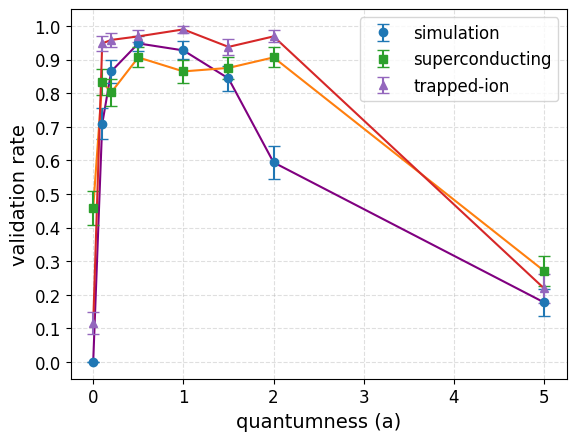

In [ ]:

simulation_accuracies = [1-sim[-1]["err"] for sim in simulation_data] 
simulation_errors = [binomial_error(sim,96) for sim in simulation_accuracies]
trapped_ion_errors = [binomial_error(acc,96) for acc in trapped_ion_accuracy]
superconducting_accuracies,errors = run_analysis(files=files,true_index=2)

plt.rcParams.update({
    "mathtext.fontset":  "cm",               # use Computer Modern for math
    "axes.labelsize":    14,
    "axes.titlesize":    16,
    "legend.fontsize":   12,
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "axes.grid":         True,
    "grid.linestyle":    "--",
    "grid.alpha":        0.4,
})

# plt.figure(figsize=(15,8))
# plt.title("Validation Rate vrs. Quatumness: 16 Qubits, 3 Layers, 96 Samples per a")

plt.plot(As, simulation_accuracies, color="purple")
plt.errorbar(x=As,y=simulation_accuracies,yerr=simulation_errors,fmt='o',capsize=4,barsabove=False,
label=r"simulation")

plt.plot(As,superconducting_accuracies)
# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=As,y=superconducting_accuracies,yerr=errors,fmt='s',capsize=4,barsabove=False,
label=r"superconducting")

plt.plot(As, trapped_ion_accuracy, )
plt.errorbar(x=As,y=trapped_ion_accuracy,yerr=trapped_ion_errors,fmt='^',capsize=4,barsabove=False,
label=r"trapped-ion")


plt.xlabel("quantumness (a)")
plt.ylabel("validation rate")

# plt.xticks(As)
plt.margins(.05)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()
# plt.grid()


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with real values)
# As = [...]
# simulation_accuracies, simulation_errors = ...
# superconducting_accuracies, errors = ...
# trapped_ion_accuracy, trapped_ion_errors = ...


plt.switch_backend("pgf")

# 2) Tell PGF to use your LaTeX installation
plt.rcParams.update({
        "axes.facecolor":   "white",  # plot background
    "pgf.texsystem": "pdflatex",   # or "xelatex", "lualatex"
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,     
             "axes.grid":     False,    # ← add this
     # don’t override your document’s fonts
})


# Define a dict of colors
colors = {
    "Superconducting Device":    "purple",  # blue
    "QASM Simulation": "coral",  # orange
    "Microwave Trapped-Ion": "skyblue",  # green
}

fig, ax = plt.subplots(figsize=(8,6))

# Simulation
ax.errorbar(
    As, simulation_accuracies, yerr=simulation_errors,
    fmt='o-',  # circle marker, dashed line
    color=colors["QASM Simulation"],
    capsize=4,
    label="QASM Simulation"
)

# Superconducting
ax.errorbar(
    As, superconducting_accuracies, yerr=errors,
    fmt='o-',  # square marker, solid line
    color=colors["Superconducting Device"],
    capsize=4,
    label="Superconducting"
)

# Trapped-ion
ax.errorbar(
    As, trapped_ion_accuracy, yerr=trapped_ion_errors,
    fmt='o-',  # triangle-up marker, dash-dot line
    color=colors["Microwave Trapped-Ion"],
    capsize=4,
    label="Microwave Trapped-ion"
)

ax.set_xlabel("Quantumness ($a$)",fontsize=22)
ax.set_ylabel("Validation rate",fontsize=22)
ax.set_xticks(list(np.arange(0,5.5,.5)))
ax.margins(x=0.1)
ax.set_ylim(0, 1.05)

ax.tick_params(axis="both", which="major", labelsize=14)
ax.tick_params(axis="both", which="minor", labelsize=12)
# If you need symlog or other scale, set here before legend
# ax.set_xscale('symlog', linthresh=0.5)

ax.legend(frameon=False, loc='best', fontsize=16)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png")
ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.9, .7, 0.1, 0.1),   # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")


plt.grid(False)
plt.tight_layout()
plt.show()

/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_59113/795371677.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_59113/795371677.py:91: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [55]:
plt.savefig("cherrypick_analysis.pdf", bbox_inches='tight', dpi=300)

In [ ]:

# simulation_accuracies = [1-sim[-1]["err"] for sim in simulation_data] 
# simulation_errors = [binomial_error(sim,96) for sim in simulation_accuracies]
# trapped_ion_errors = [binomial_error(acc,96) for acc in trapped_ion_accuracy]
# superconducting_accuracies,errors = run_analysis(files=files,true_index=2)

# plt.style.use('ggplot')  
# # plt.rcParams.update({
# #     "mathtext.fontset":  "cm",               # use Computer Modern for math
# #     "axes.labelsize":    14,
# #     "axes.titlesize":    16,
# #     "legend.fontsize":   12,
# #     "xtick.labelsize":   12,
# #     "ytick.labelsize":   12,
# #     "axes.grid":         True,
# #     "grid.linestyle":    "--",
# #     "grid.alpha":        0.4,
# # })


# plt.figure(figsize=(15,8))
# plt.title("Validation Rate vrs. Quatumness: 16 Qubits, 3 Layers, 96 Samples per a")

# plt.plot(As, simulation_accuracies, color="purple")
# plt.errorbar(x=As,y=simulation_accuracies,yerr=simulation_errors,fmt='o',capsize=4,
# ecolor="orange",barsabove=False,
# label=r"simulation device")

# plt.plot(As,superconducting_accuracies)
# # plt.scatter(As,accuracies,color="orange")
# plt.errorbar(x=As,y=superconducting_accuracies,yerr=errors,fmt='o',capsize=4,barsabove=False,
# label=r"superconducting device")

# plt.plot(As, trapped_ion_accuracy, )
# plt.errorbar(x=As,y=trapped_ion_accuracy,yerr=trapped_ion_errors,fmt='o',capsize=4,barsabove=False,
# label=r"trapped-ion device")


# plt.xlabel("quantumness (a)")
# plt.ylabel("validation rate")

# plt.xticks(As)
# plt.margins(.05)
# plt.yticks(np.arange(0, 1.1, 0.1))
# plt.legend()
# plt.grid(False)


In [ ]:
# from qiskit import QuantumCircuit
# from qiskit.quantum_info import Operator, Statevector

# # 1) Build the circuit
# qc = QuantumCircuit(3, name="three_ccx_sequence")
# # CCX on controls (0,1) -> target 0
# a,b,c = 0,1,2

# # 1) Toffoli(c, a -> b)
# qc.ccx(c, a, b)
# # 2) Toffoli(c, b -> a)
# qc.ccx(c, b, a)
# # 3) Toffoli(c, a -> b)
# qc.ccx(c, a, b)

# # You can draw or convert to Operator to verify:
# # (Optional) visualize
# print(qc.draw())

# # 2) Get the overall unitary operator
# U = Operator(qc)  # this is an 8x8 numpy-backed operator


          ┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └─┬─┘  │  └─┬─┘
q_2: ──■────■────■──
                    


In [ ]:
# mat = U.data  # NumPy array shape (8,8)
# print("Combined 8×8 matrix:\n", mat)

Combined 8×8 matrix:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


In [ ]:
# import pandas as pd
# import numpy as np
# from qiskit.quantum_info import Operator

# # get the matrix
# U = Operator(qc)
# mat = U.data

# # build basis labels
# labels = [format(i, '03b') for i in range(8)]  # ['000','001',…,'111']

# # make a DataFrame
# df = pd.DataFrame(mat, index=labels, columns=labels)

# # display it
# print(df)

          000       001       010       011       100       101       110  \
000  1.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j   
001  0.0+0.0j  1.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j   
010  0.0+0.0j  0.0+0.0j  1.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j   
011  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j   
100  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  1.0+0.0j  0.0+0.0j  0.0+0.0j   
101  0.0+0.0j  0.0+0.0j  0.0+0.0j  1.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j   
110  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  1.0+0.0j  0.0+0.0j   
111  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  0.0+0.0j  1.0+0.0j   

          111  
000  0.0+0.0j  
001  0.0+0.0j  
010  0.0+0.0j  
011  1.0+0.0j  
100  0.0+0.0j  
101  0.0+0.0j  
110  0.0+0.0j  
111  0.0+0.0j  


In [ ]:
# mat.diagonal()

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 0.+0.j, 0.+0.j])

In [ ]:
# import sympy as sp

# # Symbols
# a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p = sp.symbols('a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p', complex=True)
# # Conjugates:
# a_star = sp.conjugate(a)
# b_star = sp.conjugate(b)

# # Define U and M
# U1= sp.Matrix([[a_star, -b_star,0,0],
#                [b,  -a,0,0],
#                [0,0,1,0],
#                [0,0,0,1]])
# U = sp.Matrix([[a, b,c, d],
#                [e, f,g,h],
#                [i,j,k,l],
#                  [m,n,o,p]])

# UM = U1*U.T
# sp.pretty_print(UM)

⎡  _     _    _     _     _     _     _     _ ⎤
⎢a⋅a - b⋅b  e⋅a - f⋅b   i⋅a - j⋅b   m⋅a - n⋅b ⎥
⎢                                             ⎥
⎢    0      -a⋅f + b⋅e  -a⋅j + b⋅i  -a⋅n + b⋅m⎥
⎢                                             ⎥
⎢    c          g           k           o     ⎥
⎢                                             ⎥
⎣    d          h           l           p     ⎦


In [ ]:
# from sympy import re, im, I, E, symbols
# U1= sp.Matrix([[1, I, 0, 0],
#                [-I, -1, 0, 0],
#                [0,0,1,0],
#                [0,0,0,1]])
# U = 1/2*sp.Matrix([[1, 1,1, 1],
#                [1, I,-1,-I],
#                [1,-1,1,-1],
#                  [1,-I,-1,i]])

In [ ]:
# U1*U1.adjoint()

Matrix([
[1.25,    0, 0, 0],
[   0, 1.25, 0, 0],
[   0,    0, 1, 0],
[   0,    0, 0, 1]])

In [ ]:
# U2= sp.Matrix([[1, 0, 0,I],
#                [0, 1 , 0, 0],
#                [-I,0,0,I],
#                [0,0,0,1]])

# U2*U1*U

Matrix([
[      1.5*I,        0.5*I, -0.5*I, 0.5*I*i + 0.5 + 0.5*I],
[          0, -0.5 - 0.5*I, -1.0*I,           0.5 - 0.5*I],
[1.0 + 0.5*I,  1.0 + 0.5*I, -0.5*I, 0.5*I*i + 0.5 - 0.5*I],
[        0.5,       -0.5*I,   -0.5,                 0.5*i]])

In [ ]:
# superconducting_accuracies

[np.float64(0.4583333333333333),
 np.float64(0.8333333333333334),
 np.float64(0.8020833333333334),
 np.float64(0.90625),
 np.float64(0.8645833333333334),
 np.float64(0.875),
 np.float64(0.90625),
 np.float64(0.2708333333333333)]

In [ ]:
# import math 

# math.factorial(4)*math.factorial(4)/(math.factorial(2) *math.factorial(2))/2

72.0

In [159]:
def combinations(n, k):
    """Calculate the number of combinations of n items taken k at a time."""
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

combinations(4,2)* combinations(4,2) 

36

In [165]:
def combination_pairs(n_pairs):

   return math.factorial(2*n_pairs)/(2**n_pairs * math.factorial(n_pairs))

combination_pairs(4)

105.0

In [42]:
trapped_ion_accuracy

[0.11458333333333333,
 0.9479166666666666,
 0.9583333333333334,
 0.96875,
 0.9895833333333334,
 0.9375,
 0.96875,
 0.21875]

In [43]:
trapped_ion_errors

[0.0325086515817257,
 0.022677691801411694,
 0.02039468771609501,
 0.017758049084617,
 0.01036227116867474,
 0.024705294220065465,
 0.017758049084617,
 0.042192322255259505]